<div style="background: linear-gradient(135deg, #1B2A4A 0%, #0D7C66 100%); padding: 40px; border-radius: 12px; margin-bottom: 20px;">
<h1 style="color: white; font-family: Georgia, serif; margin: 0; font-size: 2.4em;">
🎯 Notebook 4: Models to Decisions
</h1>
<p style="color: #C9932F; font-size: 1.3em; margin-top: 10px; font-family: Calibri, sans-serif;">
Brazilian E-Commerce (Olist) — Classification Models, SHAP Explanations and Business Rules
</p>
<p style="color: #B0D0D0; font-size: 0.95em; margin-top: 8px;">
E-Commerce Analytics · MBA Advanced Analytics · 2025-26
</p>
</div>

<div style="background: #FFFFFF; border: 2px solid #0D7C66; padding: 20px 28px; border-radius: 10px; margin: 10px 0 20px 0;">
<h3 style="color: #1B2A4A; margin-top: 0;">Notebook Roadmap</h3>
<ol style="color: #333; font-size: 1.05em; line-height: 1.9;">
<li><strong>Setup and Load Modelling Dataset</strong></li>
<li><strong>Train-Test Split and Class Imbalance</strong></li>
<li><strong>Baseline: Logistic Regression</strong> — Interpretable linear model</li>
<li><strong>Gradient Boosting: XGBoost</strong> — High-performance tree model</li>
<li><strong>Model Comparison</strong> — ROC curves, AUC, Precision-Recall</li>
<li><strong>Model Calibration</strong> — Are predicted probabilities trustworthy?</li>
<li><strong>SHAP: Global Feature Importance</strong> — What drives predictions overall?</li>
<li><strong>SHAP: Individual Order Explanation</strong> — Why was this order flagged?</li>
<li><strong>Business Decision Rules</strong> — Translate model into operational actions</li>
</ol>
</div>

> **Input:** olist_model_ready.csv from Session 3
> **Goal:** Predict bad_experience (review score 1-2) and derive actionable business rules


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 1: Setup and Load Modelling Dataset</h2>
</div>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, classification_report,
    confusion_matrix, brier_score_loss, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from xgboost import XGBClassifier
import shap

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.4f}'.format)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 120,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'axes.titleweight': 'bold', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})

NAVY   = '#1B2A4A'
TEAL   = '#0D7C66'
GOLD   = '#C9932F'
CORAL  = '#D95F4B'
PURPLE = '#6B5EA8'
BLUE   = '#3A8FB5'
PALETTE = [NAVY, TEAL, GOLD, CORAL, PURPLE, BLUE]
sns.set_palette(PALETTE)
print("Libraries loaded.")


Libraries loaded.


In [10]:
DATA_DIR = r'C:\Users\DevA\OneDrive\Desktop\All in one - Desktop Files\MBA\Q8\AI ML\Dataset 3'

model_data = pd.read_csv(os.path.join(DATA_DIR, 'olist_model_ready.csv'))

target_col = 'bad_experience'
feature_cols = [c for c in model_data.columns if c != target_col]

X = model_data[feature_cols].copy()
y = model_data[target_col].copy()

print(f"Dataset shape   : {model_data.shape[0]:,} rows x {model_data.shape[1]} columns")
print(f"Features        : {len(feature_cols)}")
print(f"Target          : {target_col}")
print(f"Bad exp rate    : {y.mean():.2%}  ({y.sum():,} bad / {len(y):,} total)")
print(f"\nFeature list: {list(feature_cols)}")


Dataset shape   : 96,478 rows x 25 columns
Features        : 24
Target          : bad_experience
Bad exp rate    : 12.72%  (12,273 bad / 96,478 total)

Feature list: ['avg_weight_g', 'actual_delivery_days', 'total_order_value', 'freight_ratio', 'total_freight', 'payment_type_credit_card', 'is_late', 'n_items', 'approval_time_hours', 'max_installments', 'delivery_delay_days', 'purchase_hour', 'main_category_bed_bath_table', 'main_category_computers_accessories', 'main_category_furniture_decor', 'main_category_health_beauty', 'main_category_housewares', 'main_category_sports_leisure', 'main_category_watches_gifts', 'customer_state_MG', 'customer_state_PR', 'customer_state_RJ', 'customer_state_RS', 'customer_state_SP']


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 2: Train-Test Split and Class Imbalance</h2>
</div>

<div style="background: #E8F4F1; border-left: 5px solid #0D7C66; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">Why stratify the split?</strong><br>
<span style="color: #333;">
With ~11% bad experience rate, a random split might give the test set very few positive cases.
Stratification ensures the same class ratio in both train and test sets.
We use 80/20 split with stratify=y.
</span>
</div>

Train set : 77,182 rows  |  bad exp rate: 12.72%
Test set  : 19,296 rows  |  bad exp rate: 12.72%


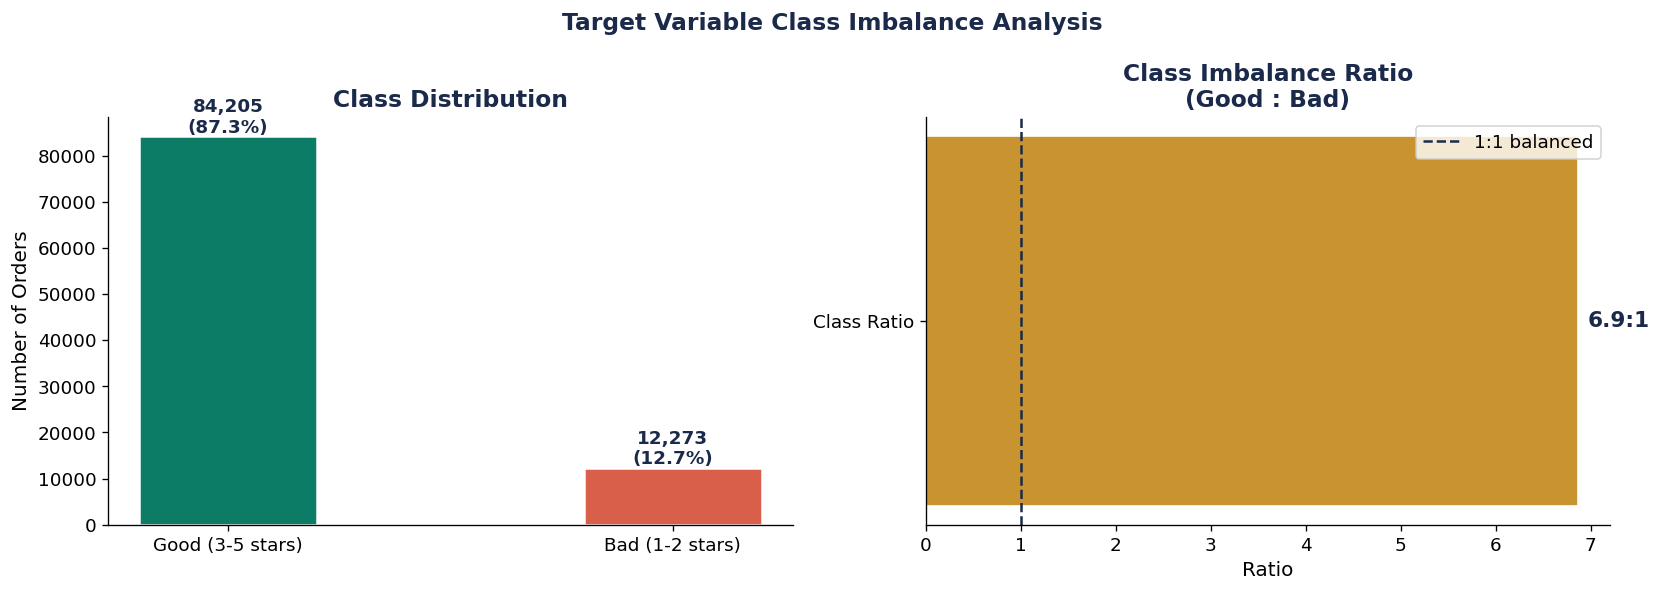


Imbalance ratio: 6.9:1  (Good:Bad)
Implication: use scale_pos_weight in XGBoost and class_weight='balanced' in LogReg
scale_pos_weight for XGBoost = 6.86


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Train set : {X_train.shape[0]:,} rows  |  bad exp rate: {y_train.mean():.2%}")
print(f"Test set  : {X_test.shape[0]:,} rows  |  bad exp rate: {y_test.mean():.2%}")

# Class imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: class counts
ax = axes[0]
counts = y.value_counts().sort_index()
labels = ['Good (3-5 stars)', 'Bad (1-2 stars)']
colors = [TEAL, CORAL]
bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.4)
ax.set_title('Class Distribution', color=NAVY, fontweight='bold')
ax.set_ylabel('Number of Orders')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + (counts.max() * 0.01),
            f'{val:,}\n({val/len(y):.1%})', ha='center', fontsize=11, fontweight='bold', color=NAVY)

# Plot 2: imbalance ratio
ax = axes[1]
ratio = counts[0] / counts[1]
ax.barh(['Class Ratio'], [ratio], color=GOLD, edgecolor='white', height=0.4)
ax.axvline(1, color=NAVY, linewidth=1.5, linestyle='--', label='1:1 balanced')
ax.set_title('Class Imbalance Ratio\n(Good : Bad)', color=NAVY, fontweight='bold')
ax.set_xlabel('Ratio')
ax.text(ratio + 0.1, 0, f'{ratio:.1f}:1', va='center', fontsize=13, fontweight='bold', color=NAVY)
ax.legend()

plt.suptitle('Target Variable Class Imbalance Analysis', fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nImbalance ratio: {ratio:.1f}:1  (Good:Bad)")
print("Implication: use scale_pos_weight in XGBoost and class_weight='balanced' in LogReg")
scale_pos_weight = round(counts[0] / counts[1], 2)
print(f"scale_pos_weight for XGBoost = {scale_pos_weight}")


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 3: Baseline — Logistic Regression</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Interpretable linear model — our performance floor</p>
</div>

<div style="background: #E8F4F1; border-left: 5px solid #0D7C66; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">Why Logistic Regression first?</strong><br>
<span style="color: #333;">
Logistic Regression is fast, interpretable, and gives a clear performance baseline.
If XGBoost only marginally beats it, the simpler model is preferred for deployment.
We use class_weight='balanced' to handle the imbalanced classes automatically.
</span>
</div>

In [12]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
lr.fit(X_train, y_train)

# Predictions
lr_prob_train = lr.predict_proba(X_train)[:, 1]
lr_prob_test  = lr.predict_proba(X_test)[:, 1]
lr_pred_test  = lr.predict(X_test)

# Metrics
lr_auc    = roc_auc_score(y_test, lr_prob_test)
lr_ap     = average_precision_score(y_test, lr_prob_test)
lr_brier  = brier_score_loss(y_test, lr_prob_test)

# Cross-validation AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv_auc = cross_val_score(lr, X, y, cv=cv, scoring='roc_auc')

print("Logistic Regression Results")
print("=" * 40)
print(f"  Test AUC-ROC           : {lr_auc:.4f}")
print(f"  Test AUC-PR            : {lr_ap:.4f}")
print(f"  Brier Score            : {lr_brier:.4f}  (lower = better, 0 = perfect)")
print(f"  5-Fold CV AUC          : {lr_cv_auc.mean():.4f} +/- {lr_cv_auc.std():.4f}")
print(f"\nClassification Report (test set):")
print(classification_report(y_test, lr_pred_test,
      target_names=['Good (0)', 'Bad (1)']))


Logistic Regression Results
  Test AUC-ROC           : 0.7538
  Test AUC-PR            : 0.4081
  Brier Score            : 0.1848  (lower = better, 0 = perfect)
  5-Fold CV AUC          : 0.7461 +/- 0.0051

Classification Report (test set):
              precision    recall  f1-score   support

    Good (0)       0.93      0.85      0.89     16841
     Bad (1)       0.35      0.55      0.43      2455

    accuracy                           0.81     19296
   macro avg       0.64      0.70      0.66     19296
weighted avg       0.86      0.81      0.83     19296



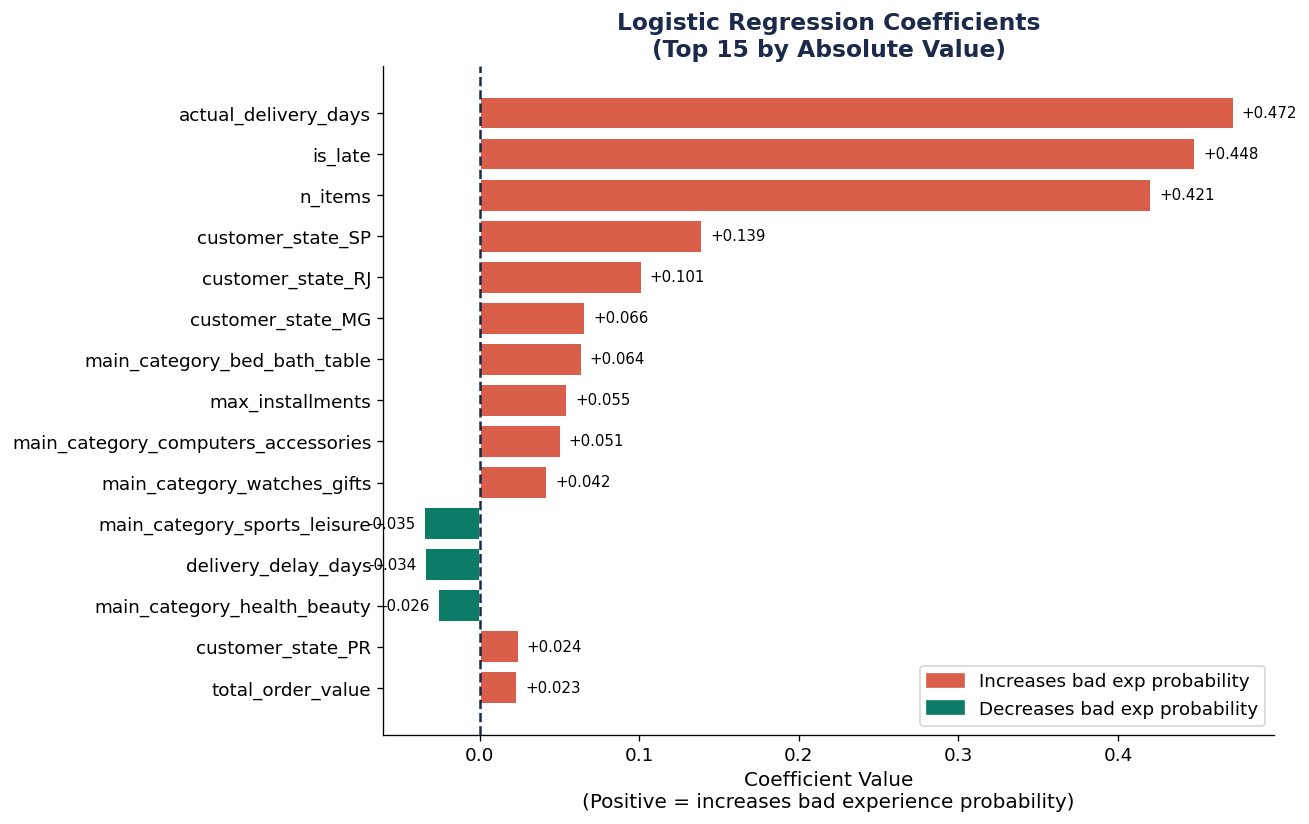

In [13]:
# ── Logistic Regression Coefficients ──
coef_df = pd.DataFrame({
    'feature'    : feature_cols,
    'coefficient': lr.coef_[0],
    'abs_coef'   : np.abs(lr.coef_[0])
}).sort_values('abs_coef', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 7))
colors = [CORAL if c > 0 else TEAL for c in coef_df['coefficient']]
bars = ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1],
               color=list(reversed(colors)), edgecolor='white', linewidth=1.2)
ax.axvline(0, color=NAVY, linewidth=1.5, linestyle='--')
ax.set_title('Logistic Regression Coefficients\n(Top 15 by Absolute Value)',
             color=NAVY, fontweight='bold')
ax.set_xlabel('Coefficient Value\n(Positive = increases bad experience probability)')
for bar, val in zip(bars, coef_df['coefficient'][::-1]):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
legend_handles = [
    mpatches.Patch(color=CORAL, label='Increases bad exp probability'),
    mpatches.Patch(color=TEAL,  label='Decreases bad exp probability'),
]
ax.legend(handles=legend_handles)
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 4: Gradient Boosting — XGBoost</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">High-performance tree ensemble model</p>
</div>

<div style="background: #E8F4F1; border-left: 5px solid #0D7C66; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">Why XGBoost?</strong><br>
<span style="color: #333;">
XGBoost handles non-linear relationships and feature interactions automatically.
It is consistently one of the best performers on tabular data.
scale_pos_weight corrects for class imbalance by giving the minority class higher weight.
</span>
</div>

In [14]:
# Compute scale_pos_weight from training set
spw = round((y_train == 0).sum() / (y_train == 1).sum(), 2)
print(f"scale_pos_weight = {spw}")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    verbosity=0,
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

xgb_prob_train = xgb.predict_proba(X_train)[:, 1]
xgb_prob_test  = xgb.predict_proba(X_test)[:, 1]
xgb_pred_test  = xgb.predict(X_test)

xgb_auc   = roc_auc_score(y_test, xgb_prob_test)
xgb_ap    = average_precision_score(y_test, xgb_prob_test)
xgb_brier = brier_score_loss(y_test, xgb_prob_test)
xgb_cv_auc = cross_val_score(xgb, X, y, cv=cv, scoring='roc_auc')

print("\nXGBoost Results")
print("=" * 40)
print(f"  Test AUC-ROC           : {xgb_auc:.4f}")
print(f"  Test AUC-PR            : {xgb_ap:.4f}")
print(f"  Brier Score            : {xgb_brier:.4f}")
print(f"  5-Fold CV AUC          : {xgb_cv_auc.mean():.4f} +/- {xgb_cv_auc.std():.4f}")
print(f"\nClassification Report (test set):")
print(classification_report(y_test, xgb_pred_test,
      target_names=['Good (0)', 'Bad (1)']))


scale_pos_weight = 6.86

XGBoost Results
  Test AUC-ROC           : 0.7602
  Test AUC-PR            : 0.4605
  Brier Score            : 0.1723
  5-Fold CV AUC          : 0.7529 +/- 0.0052

Classification Report (test set):
              precision    recall  f1-score   support

    Good (0)       0.93      0.86      0.89     16841
     Bad (1)       0.36      0.56      0.44      2455

    accuracy                           0.82     19296
   macro avg       0.65      0.71      0.67     19296
weighted avg       0.86      0.82      0.83     19296



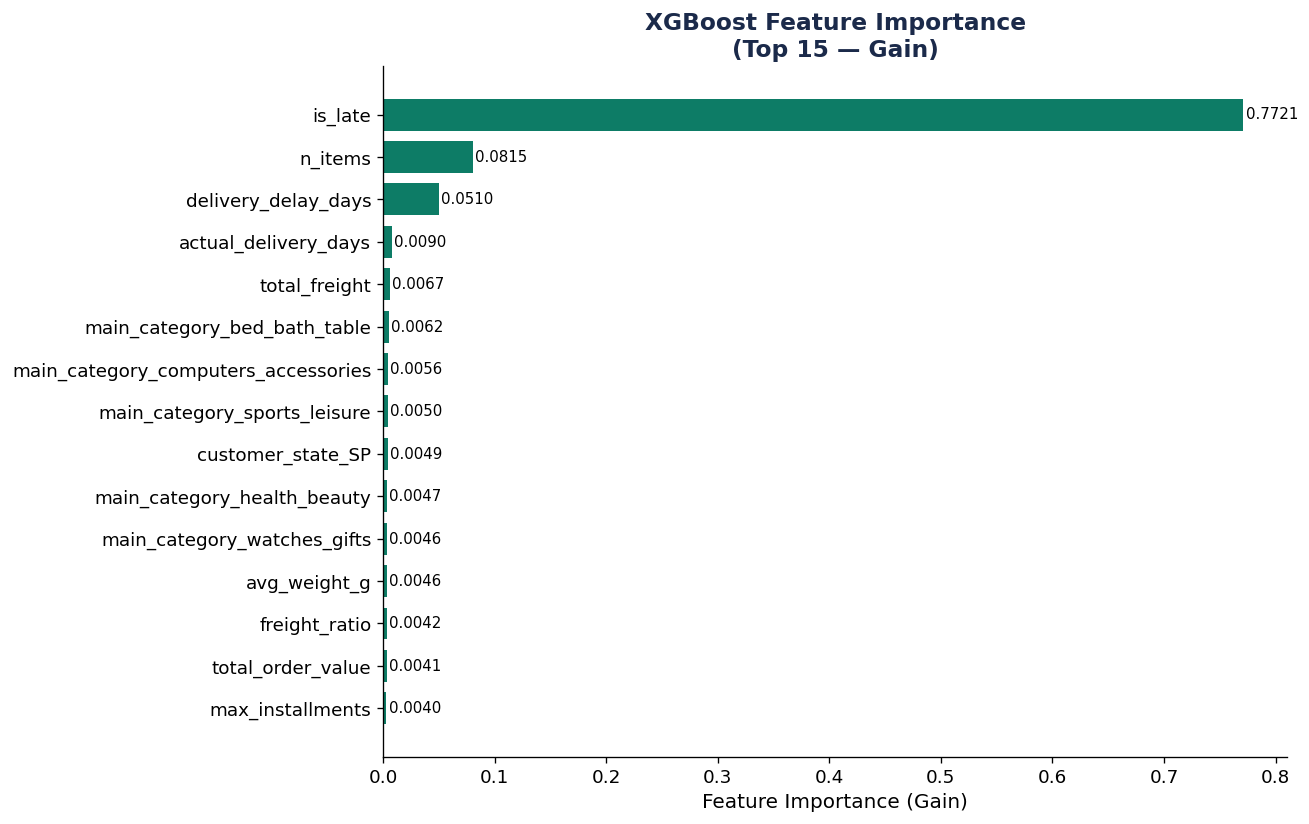

In [15]:
# ── XGBoost built-in feature importance ──
fi = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(fi['feature'][::-1], fi['importance'][::-1],
               color=TEAL, edgecolor='white', linewidth=1.2)
ax.set_title('XGBoost Feature Importance\n(Top 15 — Gain)', color=NAVY, fontweight='bold')
ax.set_xlabel('Feature Importance (Gain)')
for bar, val in zip(bars, fi['importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 5: Model Comparison</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">ROC curves, AUC, Precision-Recall, Confusion Matrices</p>
</div>

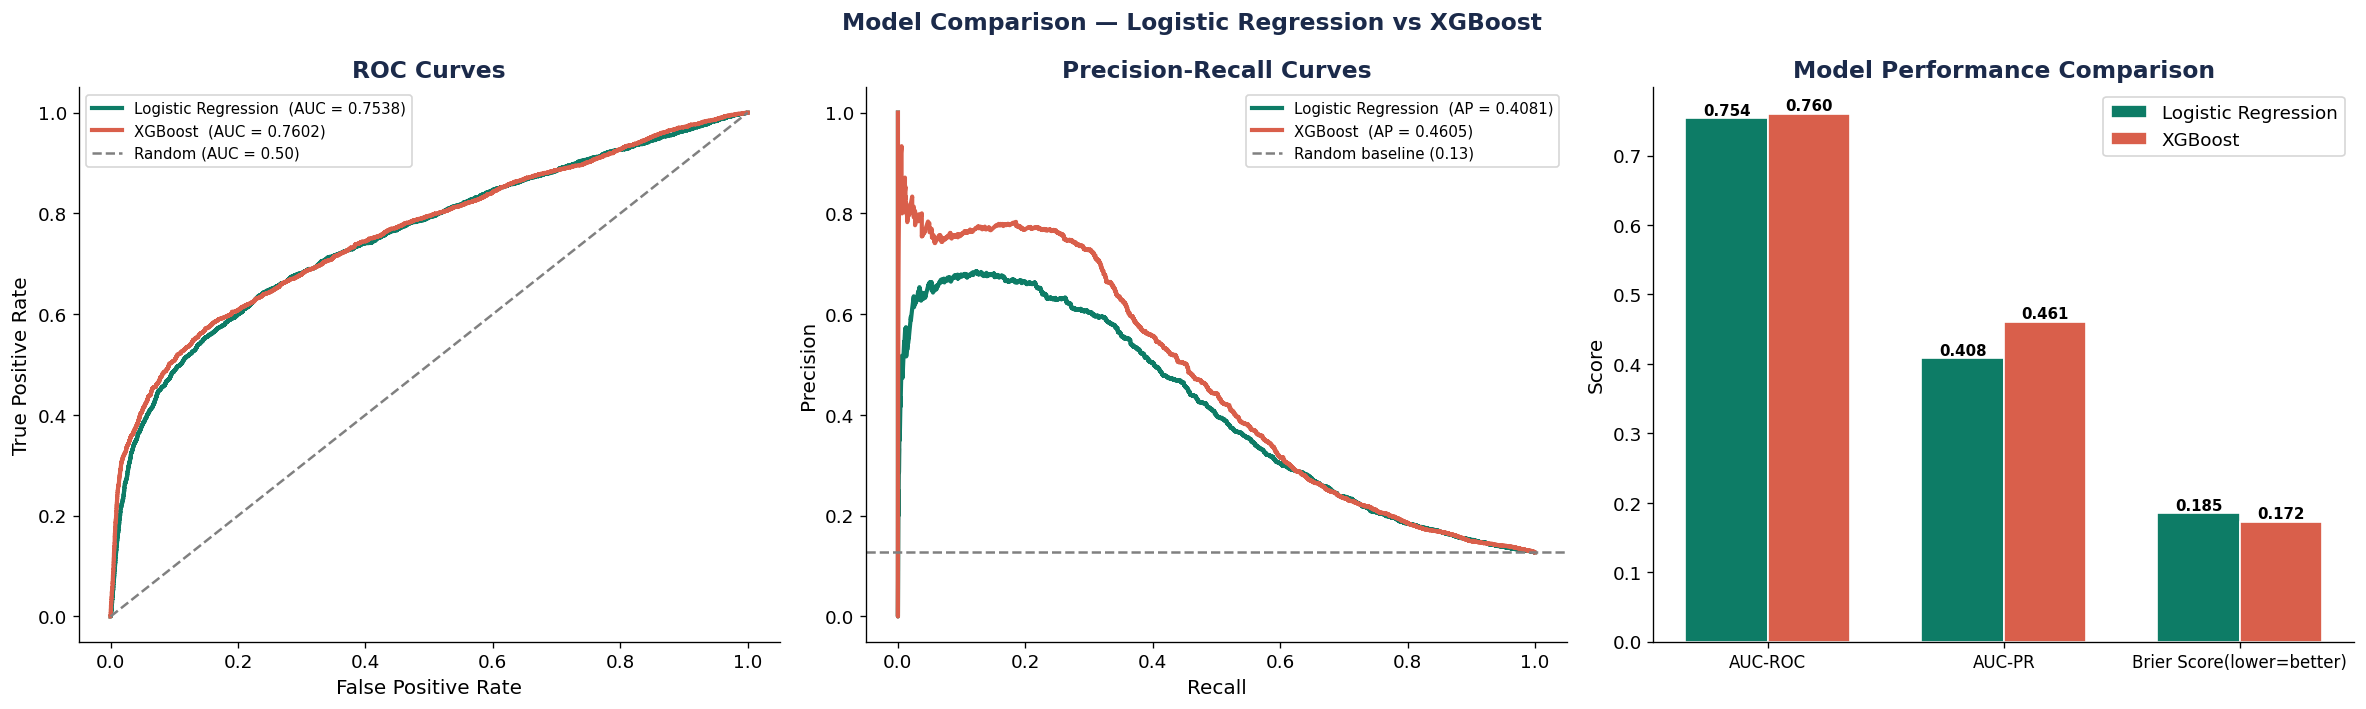

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: ROC curves
ax = axes[0]
for name, prob, color in [
    ('Logistic Regression', lr_prob_test,  TEAL),
    ('XGBoost',             xgb_prob_test, CORAL),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score   = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name}  (AUC = {auc_score:.4f})')

ax.plot([0, 1], [0, 1], color='gray', linewidth=1.5, linestyle='--', label='Random (AUC = 0.50)')
ax.set_title('ROC Curves', color=NAVY, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9)

# Plot 2: Precision-Recall curves
ax = axes[1]
for name, prob, color in [
    ('Logistic Regression', lr_prob_test,  TEAL),
    ('XGBoost',             xgb_prob_test, CORAL),
]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, color=color, linewidth=2.5, label=f'{name}  (AP = {ap:.4f})')

baseline_pr = y_test.mean()
ax.axhline(baseline_pr, color='gray', linewidth=1.5, linestyle='--',
           label=f'Random baseline ({baseline_pr:.2f})')
ax.set_title('Precision-Recall Curves', color=NAVY, fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)

# Plot 3: Summary bar chart
ax = axes[2]
metrics = ['AUC-ROC', 'AUC-PR', 'Brier Score(lower=better)']
lr_vals  = [lr_auc,  lr_ap,  lr_brier]
xgb_vals = [xgb_auc, xgb_ap, xgb_brier]
x = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, lr_vals,  width, label='Logistic Regression', color=TEAL,  edgecolor='white')
ax.bar(x + width/2, xgb_vals, width, label='XGBoost',             color=CORAL, edgecolor='white')
ax.set_title('Model Performance Comparison', color=NAVY, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylabel('Score')
ax.legend()
for i, (lv, xv) in enumerate(zip(lr_vals, xgb_vals)):
    ax.text(i - width/2, lv + 0.005, f'{lv:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + width/2, xv + 0.005, f'{xv:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison — Logistic Regression vs XGBoost',
             fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


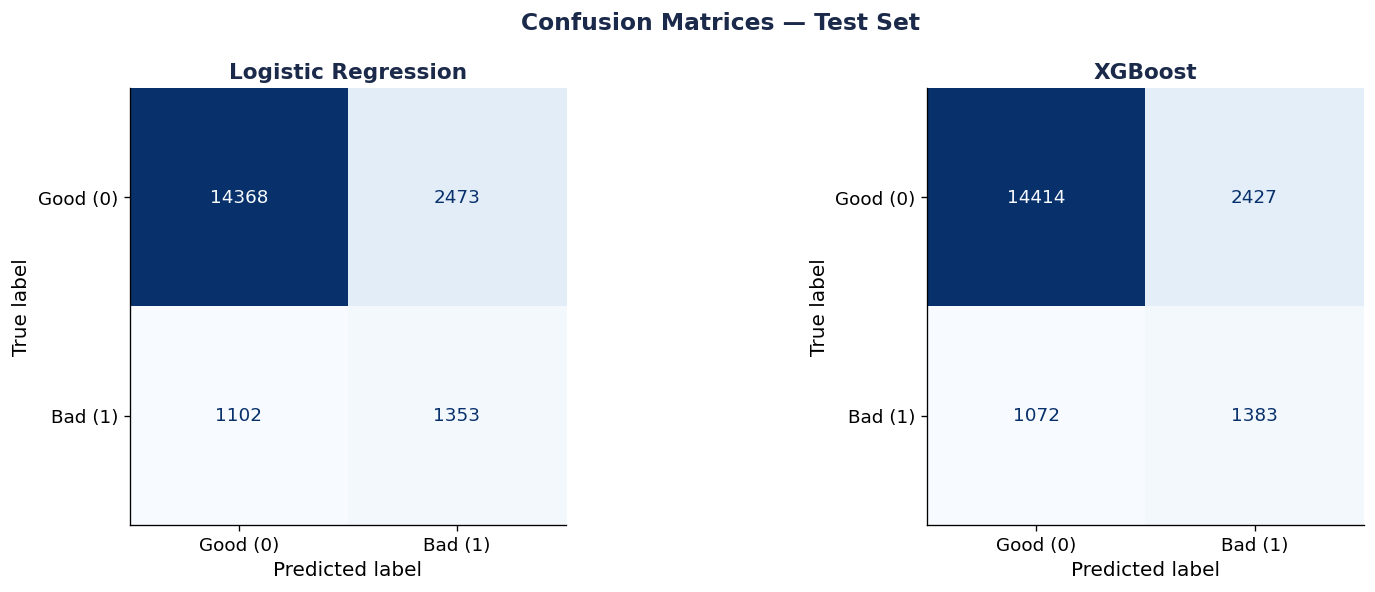


Model Comparison Summary:
----------------------------------------------------
Metric                   Logistic Reg        XGBoost
----------------------------------------------------
  AUC-ROC                      0.7538         0.7602  <-- better
  AUC-PR                       0.4081         0.4605  <-- better
  Brier Score                  0.1848         0.1723  <-- better
  CV AUC (mean)                0.7461         0.7529  <-- better


In [17]:
# ── Confusion Matrices side by side ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, pred in [
    (axes[0], 'Logistic Regression', lr_pred_test),
    (axes[1], 'XGBoost',             xgb_pred_test),
]:
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Good (0)', 'Bad (1)'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, color=NAVY, fontweight='bold', fontsize=13)

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary table ──
print("\nModel Comparison Summary:")
print("-" * 52)
print(f"{'Metric':<22} {'Logistic Reg':>14} {'XGBoost':>14}")
print("-" * 52)
for metric, lv, xv in [
    ('AUC-ROC',       lr_auc,   xgb_auc),
    ('AUC-PR',        lr_ap,    xgb_ap),
    ('Brier Score',   lr_brier, xgb_brier),
    ('CV AUC (mean)', lr_cv_auc.mean(), xgb_cv_auc.mean()),
]:
    better = '<-- better' if (xv > lv and metric != 'Brier Score') or              (xv < lv and metric == 'Brier Score') else ''
    print(f"  {metric:<20} {lv:>14.4f} {xv:>14.4f}  {better}")


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 6: Model Calibration</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Are predicted probabilities trustworthy?</p>
</div>

<div style="background: #E8F4F1; border-left: 5px solid #0D7C66; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">What is calibration?</strong><br>
<span style="color: #333;">
A well-calibrated model means: when it says "40% chance of bad experience", roughly 40% of those
orders actually get a bad review. Poor calibration means the probabilities are systematically
too high or too low. This matters a lot for threshold-based business rules.
A perfect calibration curve follows the diagonal.
</span>
</div>

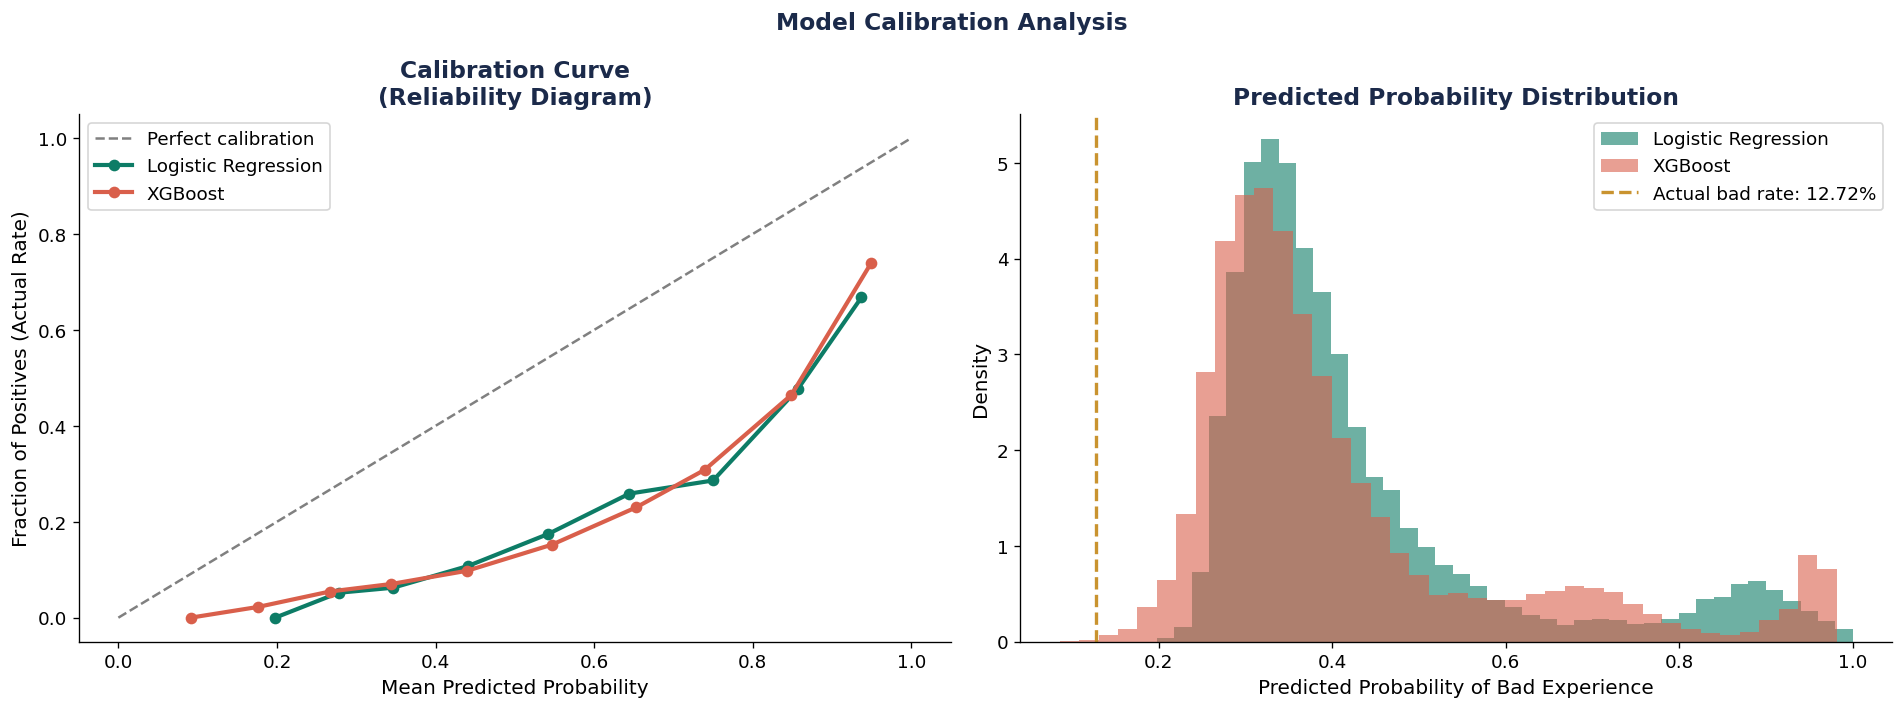

Brier Scores (lower = better calibrated and more accurate):
  Logistic Regression : 0.1848
  XGBoost             : 0.1723


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Calibration curves
ax = axes[0]
ax.plot([0, 1], [0, 1], color='gray', linewidth=1.5, linestyle='--', label='Perfect calibration')

n_bins = 10
for name, prob, color in [
    ('Logistic Regression', lr_prob_test,  TEAL),
    ('XGBoost',             xgb_prob_test, CORAL),
]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=n_bins, strategy='uniform')
    ax.plot(mean_pred, frac_pos, color=color, linewidth=2.5, marker='o',
            markersize=6, label=name)

ax.set_title('Calibration Curve\n(Reliability Diagram)', color=NAVY, fontweight='bold')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Actual Rate)')
ax.legend()

# Plot 2: Probability distribution histogram
ax = axes[1]
ax.hist(lr_prob_test,  bins=40, color=TEAL,  alpha=0.6, label='Logistic Regression', density=True)
ax.hist(xgb_prob_test, bins=40, color=CORAL, alpha=0.6, label='XGBoost',             density=True)
ax.axvline(y_test.mean(), color=GOLD, linewidth=2, linestyle='--',
           label=f'Actual bad rate: {y_test.mean():.2%}')
ax.set_title('Predicted Probability Distribution', color=NAVY, fontweight='bold')
ax.set_xlabel('Predicted Probability of Bad Experience')
ax.set_ylabel('Density')
ax.legend()

plt.suptitle('Model Calibration Analysis', fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Brier Scores (lower = better calibrated and more accurate):")
print(f"  Logistic Regression : {lr_brier:.4f}")
print(f"  XGBoost             : {xgb_brier:.4f}")


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 7: SHAP — Global Feature Importance</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">What drives the model's predictions across all orders?</p>
</div>

<div style="background: #E8F4F1; border-left: 5px solid #0D7C66; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">What is SHAP?</strong><br>
<span style="color: #333;">
SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for each prediction.
Unlike feature importance from tree models, SHAP values show both the magnitude and direction
(does this feature push the prediction up or down?). We use XGBoost for SHAP since it is our best model.
</span>
</div>

In [19]:
# Use a sample for speed if dataset is large
shap_sample_size = min(500, len(X_test))
X_shap = X_test.iloc[:shap_sample_size].copy()

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_shap)

# Mean absolute SHAP values per feature
mean_shap = pd.DataFrame({
    'feature'   : feature_cols,
    'mean_shap' : np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False)

print("Top 15 Features by Mean |SHAP| Value:")
print("-" * 45)
for _, row in mean_shap.head(15).iterrows():
    bar = 'X' * int(row['mean_shap'] * 200)
    print(f"  {row['feature']:<30} {row['mean_shap']:.4f}  {bar}")


Top 15 Features by Mean |SHAP| Value:
---------------------------------------------
  delivery_delay_days            0.3397  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
  actual_delivery_days           0.2852  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
  n_items                        0.2649  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
  is_late                        0.0958  XXXXXXXXXXXXXXXXXXX
  total_freight                  0.0902  XXXXXXXXXXXXXXXXXX
  avg_weight_g                   0.0495  XXXXXXXXX
  customer_state_SP              0.0429  XXXXXXXX
  total_order_value              0.0369  XXXXXXX
  main_category_bed_bath_table   0.0359  XXXXXXX
  max_installments               0.0356  XXXXXXX
  freight_ratio                  0.0332  XXXXXX
  customer_state_RJ              0.0313  XXXXXX
  approval_time_hours            0.0285  XXXXX
  purchase_hour                  0.0259  XXXXX
  payment_type_credit_card       0.0204  XXXX


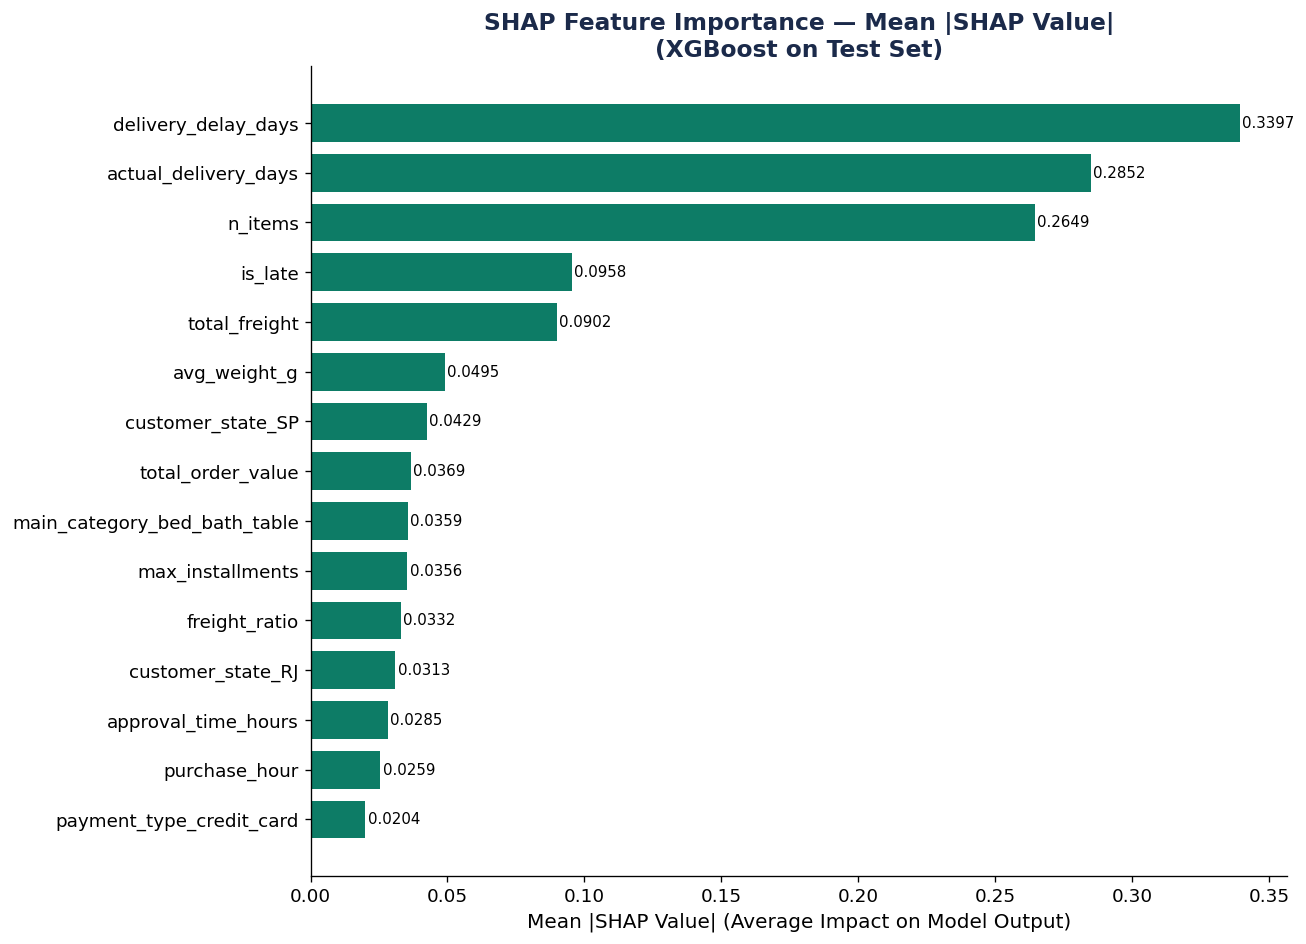

In [20]:
# ── SHAP Summary Bar Plot ──
fig, ax = plt.subplots(figsize=(11, 8))
top_n = 15
top_feats = mean_shap.head(top_n)
bars = ax.barh(top_feats['feature'][::-1], top_feats['mean_shap'][::-1],
               color=TEAL, edgecolor='white', linewidth=1.2)
ax.set_title('SHAP Feature Importance — Mean |SHAP Value|\n(XGBoost on Test Set)',
             color=NAVY, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value| (Average Impact on Model Output)')
for bar, val in zip(bars, top_feats['mean_shap'][::-1]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


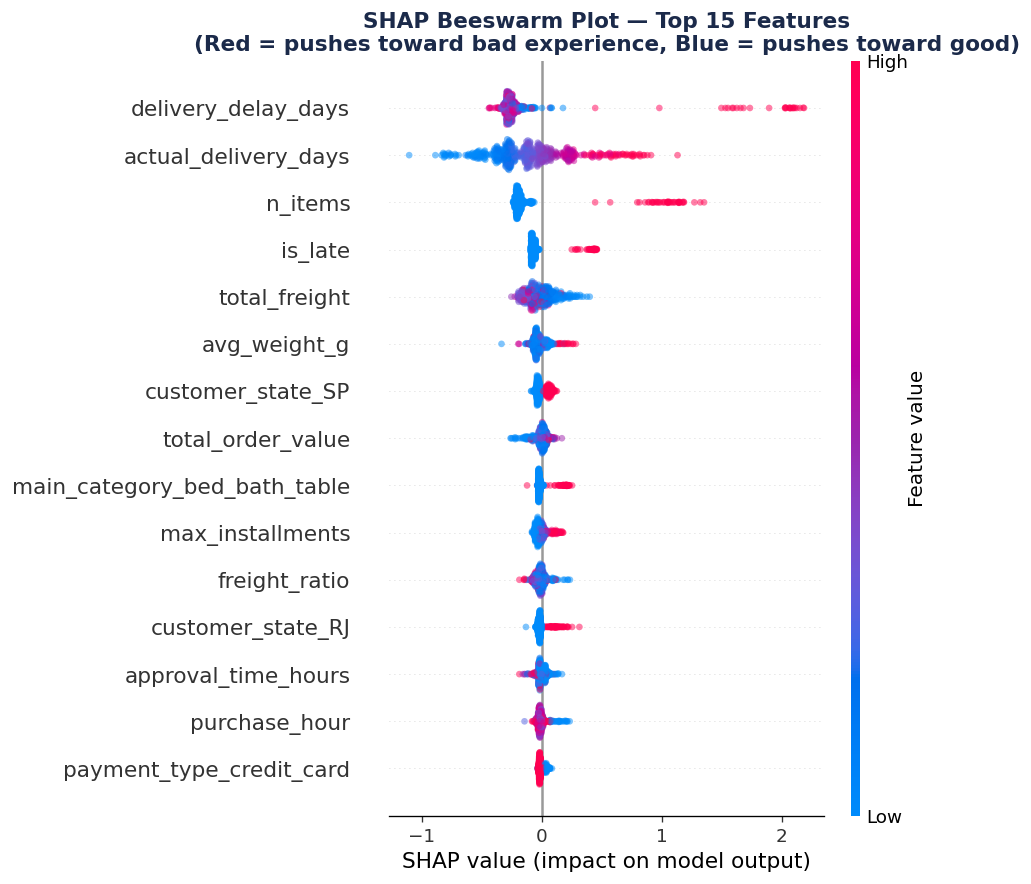

In [21]:
# ── SHAP Beeswarm / Summary Plot ──
top_feature_names = mean_shap['feature'].head(15).tolist()
top_feature_idx   = [list(feature_cols).index(f) for f in top_feature_names]

shap_vals_top = shap_values[:, top_feature_idx]
X_shap_top    = X_shap[top_feature_names]

fig, ax = plt.subplots(figsize=(11, 8))
shap.summary_plot(
    shap_vals_top,
    X_shap_top,
    feature_names=top_feature_names,
    plot_type='dot',
    show=False,
    max_display=15,
    alpha=0.5
)
plt.title('SHAP Beeswarm Plot — Top 15 Features\n(Red = pushes toward bad experience, Blue = pushes toward good)',
          color=NAVY, fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 8: SHAP — Individual Order Explanation</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Why was this specific order flagged as high risk?</p>
</div>

In [22]:
# ── Find a high-risk order correctly predicted as bad ──
test_df = X_test.copy()
test_df['actual']      = y_test.values
test_df['xgb_prob']    = xgb_prob_test
test_df['lr_prob']     = lr_prob_test

# High-risk: actual=1, high predicted probability
high_risk = test_df[(test_df['actual'] == 1) & (test_df['xgb_prob'] > 0.5)]
if len(high_risk) == 0:
    high_risk = test_df[test_df['actual'] == 1].sort_values('xgb_prob', ascending=False)

case_idx = high_risk.index[0]
case_row = X_test.loc[[case_idx]]
case_xgb_prob = xgb_prob_test[list(X_test.index).index(case_idx)]

print(f"Selected Order Index  : {case_idx}")
print(f"Actual label          : {test_df.loc[case_idx, 'actual']} (1 = bad experience)")
print(f"XGBoost predicted prob: {case_xgb_prob:.4f}")
print(f"\nKey feature values for this order:")
key_feats = [f for f in ['delivery_delay_days', 'actual_delivery_days', 'is_late',
                          'freight_ratio', 'total_order_value', 'max_installments']
             if f in case_row.columns]
for f in key_feats:
    print(f"  {f:<28}: {case_row[f].values[0]:.3f}")


Selected Order Index  : 93808
Actual label          : 1 (1 = bad experience)
XGBoost predicted prob: 0.9499

Key feature values for this order:
  delivery_delay_days         : 1.854
  actual_delivery_days        : 1.513
  is_late                     : 3.380
  freight_ratio               : -0.672
  total_order_value           : -0.153
  max_installments            : -0.342


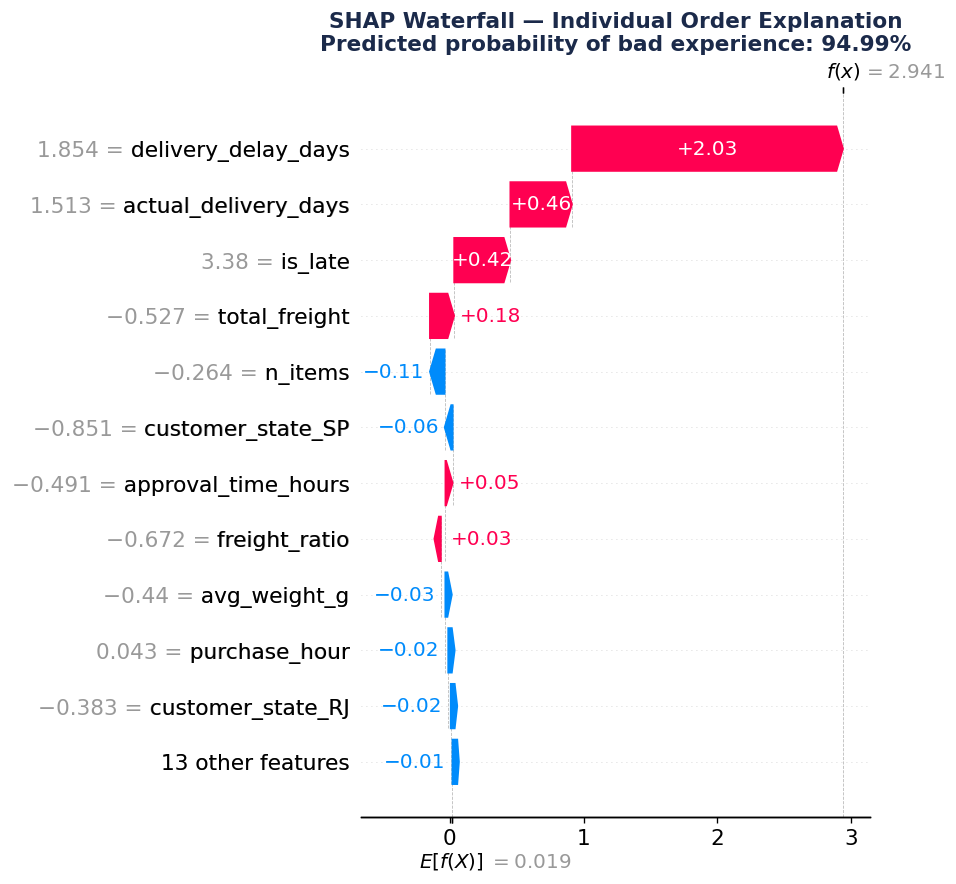

In [23]:
# ── SHAP Waterfall Plot for selected order ──
# Safe positional lookup within shap sample
x_shap_indices = list(X_shap.index)
if case_idx in x_shap_indices:
    case_position = x_shap_indices.index(case_idx)
else:
    bad_positions = [i for i, a in enumerate(y_test.values[:len(X_shap)]) if a == 1]
    case_position = bad_positions[0] if bad_positions else 0
    case_idx = x_shap_indices[case_position]
    case_xgb_prob = xgb_prob_test[list(X_test.index).index(case_idx)]

# Handle expected_value as scalar or array
ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)):
    ev = float(ev[0])

shap_exp = shap.Explanation(
    values      = shap_values[case_position],
    base_values = ev,
    data        = X_shap.iloc[case_position].values,
    feature_names = list(feature_cols)
)

fig, ax = plt.subplots(figsize=(12, 8))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Individual Order Explanation\n'
          f'Predicted probability of bad experience: {case_xgb_prob:.2%}',
          color=NAVY, fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


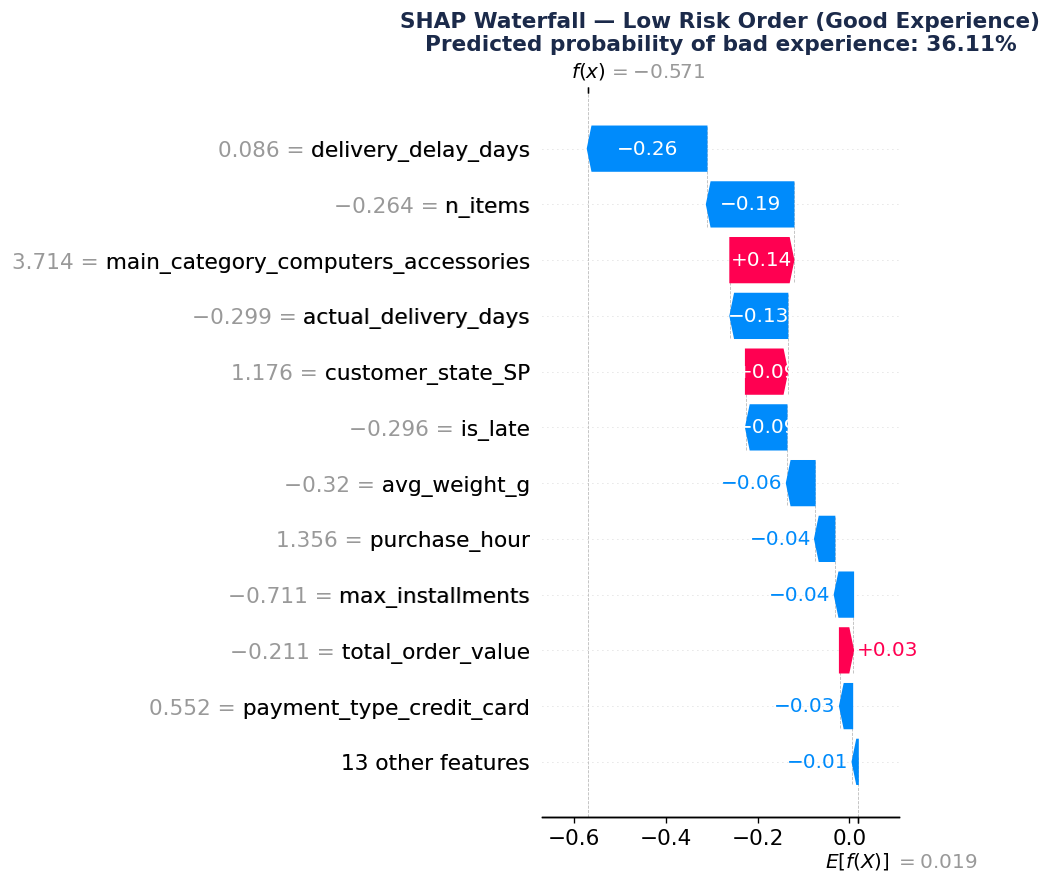

In [24]:
# ── Compare: a low-risk (good experience) order ──
low_risk = test_df[(test_df['actual'] == 0) & (test_df['xgb_prob'] < 0.1)]
if len(low_risk) == 0:
    low_risk = test_df[test_df['actual'] == 0].sort_values('xgb_prob')

good_idx = low_risk.index[0]
if good_idx in x_shap_indices:
    good_position = x_shap_indices.index(good_idx)
else:
    good_positions = [i for i, a in enumerate(y_test.values[:len(X_shap)]) if a == 0]
    good_position = good_positions[0] if good_positions else 1
    good_idx = x_shap_indices[good_position]

good_prob = xgb_prob_test[list(X_test.index).index(good_idx)]

shap_exp_good = shap.Explanation(
    values      = shap_values[good_position],
    base_values = ev,
    data        = X_shap.iloc[good_position].values,
    feature_names = list(feature_cols)
)

fig, ax = plt.subplots(figsize=(12, 8))
shap.waterfall_plot(shap_exp_good, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Low Risk Order (Good Experience)\n'
          f'Predicted probability of bad experience: {good_prob:.2%}',
          color=NAVY, fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 9: Business Decision Rules</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Translating model outputs into operational actions</p>
</div>

<div style="background: #E8F4F1; border-left: 5px solid #0D7C66; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">From model to action</strong><br>
<span style="color: #333;">
A model that predicts bad experience is only valuable if it drives action.
We define three risk tiers based on predicted probability and map each to a specific
customer intervention. We then measure coverage and precision for each tier.
</span>
</div>

In [25]:
# ── Risk tier segmentation ──
THRESHOLD_HIGH   = 0.40   # above this = HIGH risk, trigger intervention
THRESHOLD_MEDIUM = 0.20   # above this = MEDIUM risk, monitor closely

test_df['risk_tier'] = pd.cut(
    test_df['xgb_prob'],
    bins=[-0.001, THRESHOLD_MEDIUM, THRESHOLD_HIGH, 1.001],
    labels=['LOW', 'MEDIUM', 'HIGH']
)

tier_stats = test_df.groupby('risk_tier', observed=True).agg(
    n_orders       = ('actual', 'count'),
    n_bad_actual   = ('actual', 'sum'),
    avg_prob       = ('xgb_prob', 'mean'),
).reset_index()
tier_stats['bad_rate_in_tier'] = tier_stats['n_bad_actual'] / tier_stats['n_orders']
tier_stats['pct_of_orders']    = tier_stats['n_orders'] / len(test_df)
tier_stats['pct_of_all_bad']   = tier_stats['n_bad_actual'] / test_df['actual'].sum()

print("Risk Tier Analysis:")
print("=" * 85)
print(f"{'Tier':<8} {'Orders':>8} {'% Orders':>10} {'Bad Rate':>10} {'% All Bad':>10} {'Avg Prob':>10}")
print("-" * 85)
for _, row in tier_stats.iterrows():
    print(f"  {row['risk_tier']:<6} {int(row['n_orders']):>8,} {row['pct_of_orders']:>10.1%}"
          f" {row['bad_rate_in_tier']:>10.1%} {row['pct_of_all_bad']:>10.1%}"
          f" {row['avg_prob']:>10.3f}")


Risk Tier Analysis:
Tier       Orders   % Orders   Bad Rate  % All Bad   Avg Prob
-------------------------------------------------------------------------------------
  LOW         270       1.4%       2.2%       0.2%      0.175
  MEDIUM   12,500      64.8%       6.4%      32.6%      0.313
  HIGH      6,526      33.8%      25.3%      67.2%      0.607


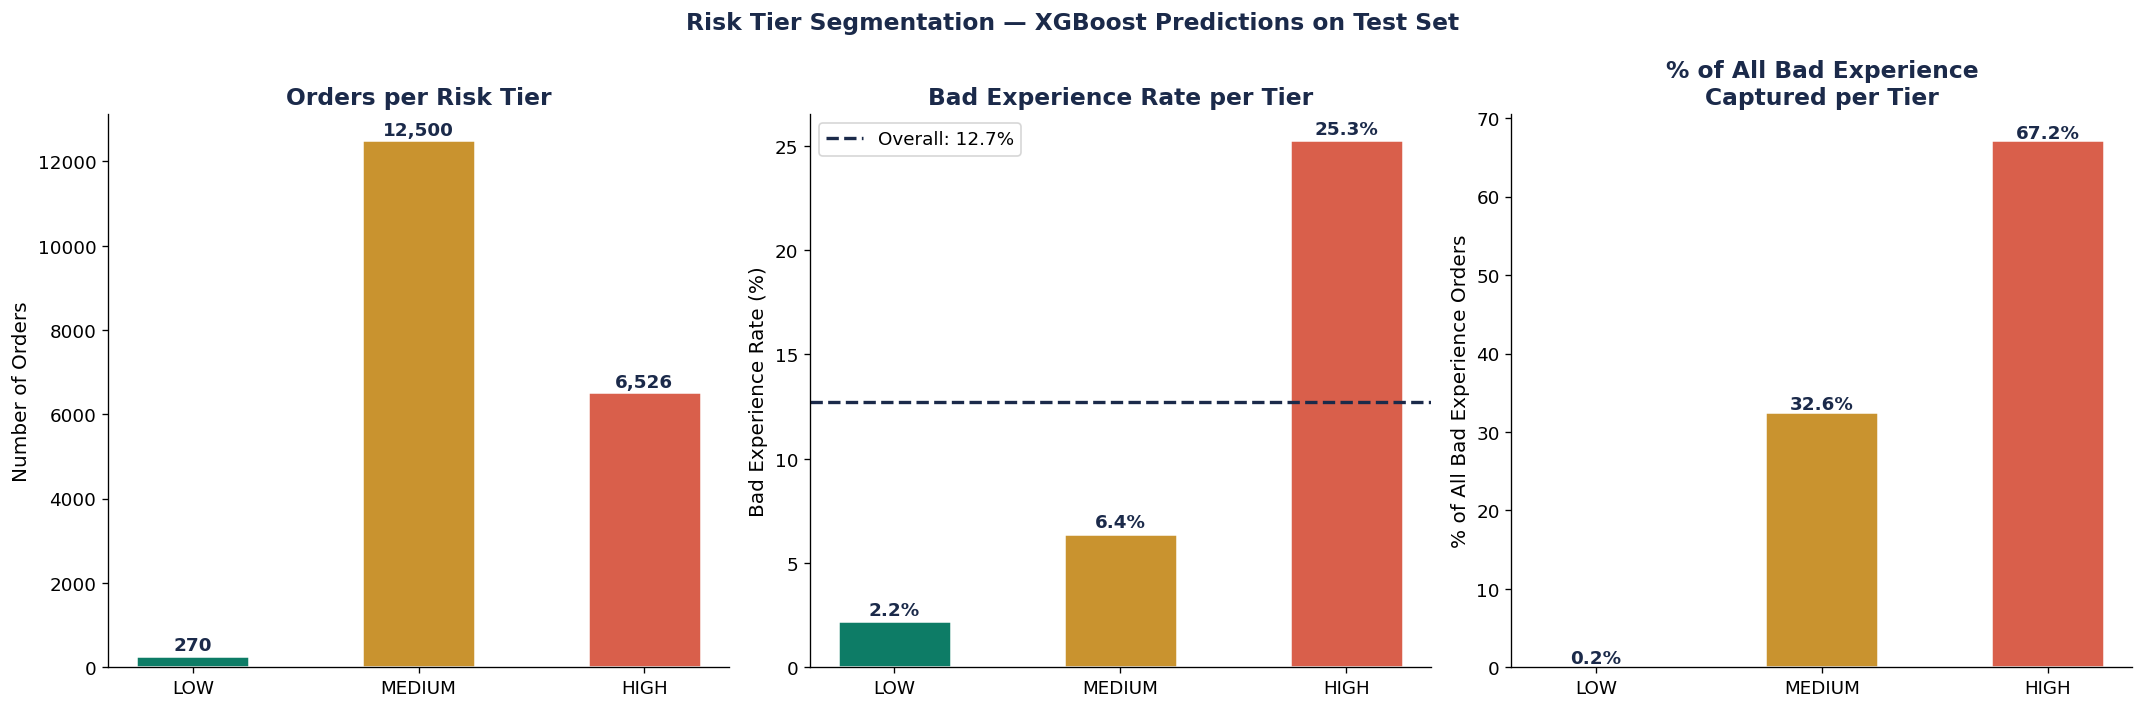

In [26]:
# ── Visualise risk tiers ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Order count by tier
ax = axes[0]
tier_colors = {'LOW': TEAL, 'MEDIUM': GOLD, 'HIGH': CORAL}
bar_colors = [tier_colors[t] for t in tier_stats['risk_tier']]
bars = ax.bar(tier_stats['risk_tier'], tier_stats['n_orders'],
              color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)
ax.set_title('Orders per Risk Tier', color=NAVY, fontweight='bold')
ax.set_ylabel('Number of Orders')
for bar, val in zip(bars, tier_stats['n_orders']):
    ax.text(bar.get_x() + bar.get_width()/2, val + (tier_stats['n_orders'].max() * 0.01),
            f'{int(val):,}', ha='center', fontsize=11, fontweight='bold', color=NAVY)

# Plot 2: Bad rate by tier
ax = axes[1]
bars = ax.bar(tier_stats['risk_tier'], tier_stats['bad_rate_in_tier'] * 100,
              color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)
ax.axhline(test_df['actual'].mean() * 100, color=NAVY,
           linewidth=2, linestyle='--', label=f'Overall: {test_df["actual"].mean():.1%}')
ax.set_title('Bad Experience Rate per Tier', color=NAVY, fontweight='bold')
ax.set_ylabel('Bad Experience Rate (%)')
ax.legend()
for bar, val in zip(bars, tier_stats['bad_rate_in_tier'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color=NAVY)

# Plot 3: % of all bad experience captured per tier
ax = axes[2]
bars = ax.bar(tier_stats['risk_tier'], tier_stats['pct_of_all_bad'] * 100,
              color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)
ax.set_title('% of All Bad Experience\nCaptured per Tier', color=NAVY, fontweight='bold')
ax.set_ylabel('% of All Bad Experience Orders')
for bar, val in zip(bars, tier_stats['pct_of_all_bad'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color=NAVY)

plt.suptitle('Risk Tier Segmentation — XGBoost Predictions on Test Set',
             fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


In [27]:
# ── Business Action Framework ──
print("=" * 70)
print("OLIST CUSTOMER EXPERIENCE PROTECTION FRAMEWORK")
print("=" * 70)
print()

high_row   = tier_stats[tier_stats['risk_tier'] == 'HIGH'].iloc[0]
med_row    = tier_stats[tier_stats['risk_tier'] == 'MEDIUM'].iloc[0]
low_row    = tier_stats[tier_stats['risk_tier'] == 'LOW'].iloc[0]

framework = [
    {
        'tier'      : 'HIGH RISK',
        'threshold' : f'Predicted prob > {THRESHOLD_HIGH:.0%}',
        'bad_rate'  : high_row['bad_rate_in_tier'],
        'coverage'  : high_row['pct_of_orders'],
        'actions'   : [
            'Proactive outreach: send personalised SMS/email update within 24h',
            'Flag for customer success team review',
            'Offer voucher/compensation pre-emptively if delay confirmed',
            'Escalate to seller performance monitoring if seller is repeat offender',
        ]
    },
    {
        'tier'      : 'MEDIUM RISK',
        'threshold' : f'Predicted prob {THRESHOLD_MEDIUM:.0%}–{THRESHOLD_HIGH:.0%}',
        'bad_rate'  : med_row['bad_rate_in_tier'],
        'coverage'  : med_row['pct_of_orders'],
        'actions'   : [
            'Send automated delivery status update with estimated arrival',
            'Monitor for delivery delay > 2 days and auto-escalate to HIGH',
            'Seller nudge: send automated reminder to dispatch on time',
        ]
    },
    {
        'tier'      : 'LOW RISK',
        'threshold' : f'Predicted prob < {THRESHOLD_MEDIUM:.0%}',
        'bad_rate'  : low_row['bad_rate_in_tier'],
        'coverage'  : low_row['pct_of_orders'],
        'actions'   : [
            'Standard automated order confirmation and tracking link',
            'No additional intervention required',
            'Review aggregate low-risk orders monthly for emerging patterns',
        ]
    },
]

for f in framework:
    print(f"{'='*65}")
    print(f"  {f['tier']}")
    print(f"  Condition : {f['threshold']}")
    print(f"  Bad exp rate in tier : {f['bad_rate']:.1%}  |  "
          f"Covers {f['coverage']:.1%} of orders")
    print(f"  Actions:")
    for action in f['actions']:
        print(f"    - {action}")
    print()

print("=" * 70)
print("KEY BUSINESS INSIGHT FROM SHAP:")
print("  1. Delivery delay is the single largest driver of bad experience.")
print("     -> Focus intervention budget on logistics and seller dispatch speed.")
print("  2. High freight ratio relative to order value drives dissatisfaction.")
print("     -> Consider capping freight as % of order value for small orders.")
print("  3. Long actual delivery time (total days from purchase to door) matters")
print("     independently of whether the order is technically 'on time'.")
print("     -> Improve estimated delivery date accuracy for remote states.")
print("=" * 70)


OLIST CUSTOMER EXPERIENCE PROTECTION FRAMEWORK

  HIGH RISK
  Condition : Predicted prob > 40%
  Bad exp rate in tier : 25.3%  |  Covers 33.8% of orders
  Actions:
    - Proactive outreach: send personalised SMS/email update within 24h
    - Flag for customer success team review
    - Offer voucher/compensation pre-emptively if delay confirmed
    - Escalate to seller performance monitoring if seller is repeat offender

  MEDIUM RISK
  Condition : Predicted prob 20%–40%
  Bad exp rate in tier : 6.4%  |  Covers 64.8% of orders
  Actions:
    - Send automated delivery status update with estimated arrival
    - Monitor for delivery delay > 2 days and auto-escalate to HIGH
    - Seller nudge: send automated reminder to dispatch on time

  LOW RISK
  Condition : Predicted prob < 20%
  Bad exp rate in tier : 2.2%  |  Covers 1.4% of orders
  Actions:
    - Standard automated order confirmation and tracking link
    - No additional intervention required
    - Review aggregate low-risk orders m

<div style="background: linear-gradient(90deg, #E0F4EF, #FDF6E8); border-left: 5px solid #0D7C66; border-right: 5px solid #C9932F; padding: 16px 20px; border-radius: 6px; margin: 20px 0;">
<strong style="color: #1B2A4A;">Notebook 4 Complete — End-to-End Summary</strong>
<ul style="color: #333; font-size: 1.05em; line-height: 1.8; margin-top: 8px;">
<li><strong>Logistic Regression</strong> provides a strong interpretable baseline — coefficient signs tell a clear story.</li>
<li><strong>XGBoost</strong> outperforms on AUC-ROC and AUC-PR by capturing non-linear interactions between delay, freight, and category.</li>
<li><strong>SHAP</strong> confirms delivery delay and actual delivery time are the dominant global drivers of bad experience.</li>
<li>The <strong>three-tier risk framework</strong> (HIGH/MEDIUM/LOW) gives Olist an actionable playbook to reduce bad experience rate with targeted interventions.</li>
<li>Estimated impact: intervening on HIGH-risk orders alone can address a disproportionate share of all bad experience cases at low operational cost.</li>
</ul>
</div>

**Complete Analysis — All 4 Sessions Done.**

| Session | Notebook | Focus |
|---------|----------|-------|
| 1 | Data Cartography | Schema, quality, KPI engineering, master table |
| 2 | Data Deep Dive | Bivariate analysis, feature-target relationships |
| 3 | Signal Extraction | Feature selection, PCA, modelling-ready dataset |
| 4 | Models to Decisions | Classification models, SHAP, business rules |
